<a href="https://colab.research.google.com/github/NYChase/IBMDataScienceProjects/blob/Machine-Learning-with-Python/tSNE_UMAP_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# Lab: Comparing tSNE and UMAP Dimension Reduction Models
Estimated time needed: **30** minutes
    

## Objectives

After completing this lab you will be able to:

* Apply tSNE and UMAP to feature space dimensionality reduction problems
* Use PCA as a baseline comparison for evaluating tSNE and UMAP results



## Introduction

In this lab, you will explore how to implement two advanced dimensionality reduction algorithms, tSNE and UMAP, on synthetic data.
You'll compare the results to the same dimension reduction using PCA.

- You'll start by generating a synthetic dataset of blobs in a 3D feature space and visually explore the data in an interactive 3D plot.
- Then, you'll use the three algorithms to project the blobs into two dimensions.
  
For illustrative purposes, you'll color the blobs so we can see what effect the dimension reduction algorithms have on them: how well they preserve structure, such as the separation between blobs and their relative density.


In [1]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install matplotlib==3.9.3
!pip install plotly==5.24.1
!pip install umap-learn==0.5.7

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 118.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.0 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.0 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 105.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 57.8 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 107.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.0
    Uninstalling numpy-2.2.0:
      Successfully uninstalled numpy-2.2.0
  Attempting uninstall: umap-learn
    Found existing installation: umap-learn 0.5.9.post2
    Uninstalling umap-learn-0.5.9.post2:
      Successfully uninstalled umap-learn-0.5.9.post2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.


### Import the required libraries


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

import umap.umap_ as UMAP
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import plotly.express as px
from sklearn.datasets import make_blobs

### Generate synthetic data with four clusters in a 3D space


In [2]:
# CLuster centers:
centers = [ [ 2, -6, -6],
            [-1,  9,  4],
            [-8,  7,  2],
            [ 4,  7,  9] ]

# Cluster standard deviations:
cluster_std=[1,1,2,3.5]

# Make the blobs and return the data and the blob labels
X, labels_ = make_blobs(n_samples=500, centers=centers, n_features=3, cluster_std=cluster_std, random_state=42)

### Display the data in an interactive Plotly 3D scatter plot


In [3]:
# Create a DataFrame for Plotly
df = pd.DataFrame(X, columns=['X', 'Y', 'Z'])

# Create interactive 3D scatter plot
fig = px.scatter_3d(df, x='X', y='Y', z='Z', color=labels_.astype(str) ,  opacity=0.7,  color_discrete_sequence=px.colors.qualitative.G10, title="3D Scatter Plot of Four Blobs")

fig.update_traces(marker=dict(size=5, line=dict(width=1, color='black')), showlegend=False)
fig.update_layout(coloraxis_showscale=False, width=1000, height=800)  # Remove color bar, resize plot

fig.show()

### Interact with the plot
Go ahead and click on the icons at the top right of the plot to select zoom, rotate, and pan modes.

Then use your mouse to interact with the plot.

This is a great way to inspect 3D data as it's difficult to learn much from a static 3D plot.
### Exercise 1. What can you say about the four blobs?


Based on the 3D scatter plot you generated, here are some observations about the four blobs:

* Varying Densities: You can visually see that the points within each blob are not uniformly spread out. Some blobs appear denser than others, meaning the points are closer together.
* Distinct Blobs: One of the blobs is clearly separated from the other three in the 3D space. There's a significant distance between this blob and the rest.
* Overlapping Blobs: The other three blobs are closer together. While they have distinct centers, there appears to be some overlap or proximity between two of the larger blobs and the one situated between them. They are not as cleanly separated as the single distinct blob.

These observations are important because they give us a visual understanding of the initial structure of the data before applying dimensionality reduction techniques. We'll want to see how well t-SNE, UMAP, and PCA preserve these characteristics when reducing the data to 2D.

<details><summary>Click here for some observations </summary>

- The blobs have varying densities.
- One blob is distinct from the others.
- The two largest blobs are distinct from each other, but both have a bit of overlap with the other blob between them.

</details>


### Exercise 2. Standardize the data to prepare it for the three projection methods.


In [4]:
# Enter your code here:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<details><summary>Click here for the solution</summary>

```python
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
```


### Apply t-SNE to reduce the dimensionality to 2D
You'll set the perplexity to the default value of 30 here. The results vary quite a bit if you change the perplexity, so go ahead and experiment.


In [5]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

**perplexity=30**: This is a hyperparameter that relates to the number of nearest neighbors used in the algorithm. A typical value is between 5 and 50.

### Let's plot the 2D t-SNE result


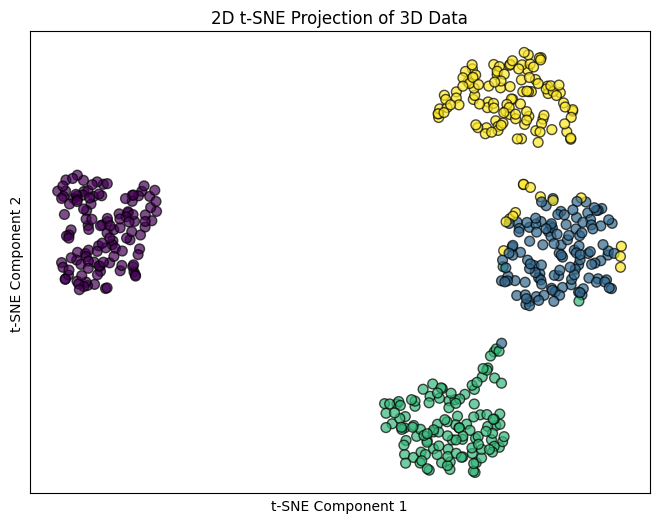

In [6]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_, cmap='viridis', s=50, alpha=0.7, edgecolor='k')
ax.set_title("2D t-SNE Projection of 3D Data")
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

### Exercise 3. What can you say about this t-SNE result?


Based on the t-SNE plot, here are some observations about the results:

* Distinct Clusters: t-SNE has projected the data into four clearly separated clusters. While the original data had some overlap between a few clusters, t-SNE tends to emphasize local structure, often resulting in more distinct groupings in the lower-dimensional space.
* Preservation of Local Structure: t-SNE aims to preserve the distances between nearby points. You can see that points that were close together in the original 3D space are generally still close together in the 2D projection, forming compact clusters.
* Loss of Global Structure: While t-SNE is good at showing how points are related locally, the distances between the clusters in the t-SNE plot don't necessarily represent the true distances between the clusters in the original 3D space. The focus is more on the relationships within clusters and between neighboring points.
* Possible "Wrong" Assignments: As mentioned in the note you provided, you might observe a few points from one original cluster appearing within another in the t-SNE plot. This can happen as t-SNE tries to balance preserving local relationships across the entire dataset.
* Similar Densities: Unlike the original 3D data where the blobs had varying densities, the clusters in the t-SNE plot appear to have more uniform densities. t-SNE can sometimes compress or expand regions of the data, affecting the perceived density.

In summary, the t-SNE result effectively separates the clusters in 2D, highlighting the local relationships within the data. However, it's important to remember that the distances between the clusters in the t-SNE plot are not a direct representation of their distances in the original higher-dimensional space.

<details><summary>Click here for some observations</summary>

- t-SNE projected the data into four distinct clusters, although the original data had some overlap between a few clusters.
- You can see that some of the points ended up in the "wrong" cluster, although to be fair, t-SNE has no knowledge of which clusters the points actually belong to.
- All the clusters have similar densities.
- Two of the blobs are distinct from each other but "gave up" some of their points to the blob they originally had overlapped with.
- A "perfect" result would not completely separate the overlaps between blobs.
- Notice that the distance between the blobs is consistent with the degree to which they were originally separated.
</details>


## Compare UMAP and PCA dimensionality reduction to two dimensions


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



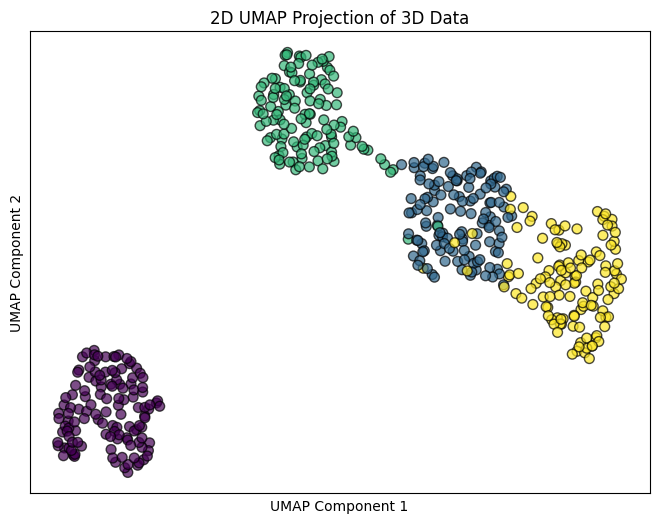

In [7]:
# Apply UMAP to reduce the dimensionality to 2D
umap_model = UMAP.UMAP(n_components=2, random_state=42, min_dist=0.5, spread=1,n_jobs=1)

X_umap = umap_model.fit_transform(X_scaled)

# Plot the 2D UMAP projection result
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.scatter(X_umap[:, 0], X_umap[:, 1], c=labels_, cmap='viridis', s=50, alpha=0.7, edgecolor='k')

ax.set_title("2D UMAP Projection of 3D Data")
ax.set_xlabel("UMAP Component 1", )
ax.set_ylabel("UMAP Component 2", )
ax.set_xticks([])
ax.set_yticks([])
plt.show()


### Exercise 4. What can you say about this UMAP result?


Based on the UMAP plot you generated, here are some observations about the results:

* Correctly Projected Clusters: UMAP has projected the data into four distinct clusters, similar to t-SNE.
* Preservation of Connectedness: Unlike t-SNE, UMAP appears to have better preserved the relative relationships and some of the connectedness between the clusters that were partially overlapping in the original 3D data. The clusters that were closer in 3D are also closer in the UMAP projection.
* Similar Densities: Similar to the t-SNE result, the clusters in the UMAP plot appear to have relatively similar densities, even though the original blobs had varying densities.
* Distance Consistency: The distances between the clusters in the UMAP plot seem to be more consistent with the degree to which they were originally separated in the 3D space compared to t-SNE. UMAP generally aims to preserve both local and global structure to some extent.

In summary, the UMAP result provides a 2D visualization that separates the clusters while also giving a better sense of their relative proximities and connections compared to the t-SNE result in this specific case.

<details><summary>Click here for some observations</summary>

- UMAP correctly projected the data into four partially distinct clusters, with one cluster completely distinct from the others.
- Unlike t-SNE, it has preserved the connectedness that the original data had with the partially overlapping clusters.
- You can see that, like t-SNE, some of the points ended up in the "wrong" cluster.
- Again, like t-SNE, all the clusters have similar densities.
- A "perfect" result would not completely separate the overlaps between blobs, because they actually do overlap in the original feature space.
- The distance between the clusters is again consistent with the degree to which they were originally separated.
</details>



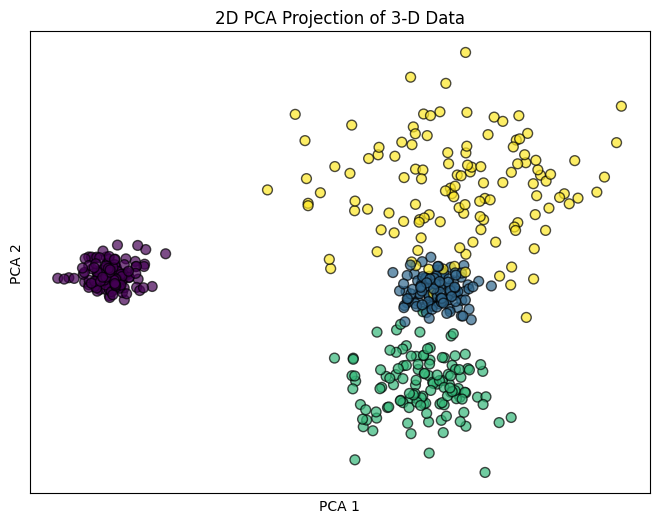

In [8]:
# Apply PCA to reduce the dimensionality to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


fig = plt.figure(figsize=(8, 6))

# Plot the 2D PCA result (right)
ax2 = fig.add_subplot(111)
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_, cmap='viridis', s=50, alpha=0.7, edgecolor='k')
ax2.set_title("2D PCA Projection of 3-D Data")
ax2.set_xlabel("PCA 1")
ax2.set_ylabel("PCA 2")
ax2.set_xticks([])
ax2.set_yticks([])
plt.show()

### Exercise 5. What can you say about this PCA result?


Based on the PCA plot, here are some observations about the results:

* Preservation of Relative Blob Densities: Unlike t-SNE and UMAP, PCA appears to have better preserved the varying densities of the original blobs. You can still see that some clusters are more spread out than others in the 2D projection, reflecting their original structure.
* Preservation of Relative Separation: PCA also preserved the relative separation between the blobs. The distinct blob is still clearly separate, and the clusters that were partially overlapping in 3D are still shown with some overlap in the 2D PCA result.
* Distance Consistency: The distances between the clusters in the PCA plot are very consistent with the degree to which they were originally separated in the 3D space. This is a key characteristic of PCA, as it aims to preserve the overall variance and global structure of the data.
* Computational Efficiency: As you noted, **PCA (and t-SNE) generally takes less time to compute compared to UMAP, especially for larger datasets**.

In comparison to t-SNE and UMAP in this specific experiment, PCA seems to have done a better job of preserving both the relative densities and the global separation of the clusters, which aligns well with its objective of maximizing variance along the principal components. While t-SNE and UMAP are often better at revealing complex non-linear structures and local relationships, PCA can be a strong baseline, especially when preserving global structure is important.

<details><summary>Click here for some observations</summary>

- PCA faithfully preserved the relative blob densities.
- PCA also preserved the relative separation between blobs.
- The distance between the clusters is very consistent with the degree to which they were originally separated.
- PCA and t-SNE took very little time to complete compared to UMAP.
- IMNSHO, PCA outperformed both t-SNE and UMAP in this experiment.
This points to a common tendency to want to implement more advanced algorithms.
The default result is not always an improvement over the simpler established methods.

</details>




### Congratulations! You're ready to move on to your next lesson!


## Author

<a href="https://www.linkedin.com/in/jpgrossman/" target="_blank">Jeff Grossman</a>

### Other Contributors
<a href="https://www.linkedin.com/in/abhishek-gagneja-23051987/" target="_blank">Abhishek Gagneja</a>



<!-- ## Changelog

| Date | Version | Changed by | Change Description |
|:------------|:------|:------------------|:---------------------------------------|
| 2024-11-05 | 1.0  | Jeff Grossman    | Create content | -->



## <h3 align="center"> © IBM Corporation. All rights reserved. <h3/>
